In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../../data/treated/go_emotions_treated.csv")

print(df.shape)
df.head(3)

(54234, 41)


,id,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,...,UNCLEAN_TEXT_PT,BASE_TEXT_PT,TEXT_NO_STOP_PT,TEXT_LEMMA_PT,CLEAN_TEXT_PT,UNCLEAN_TEXT_EN,BASE_TEXT_EN,TEXT_NO_STOP_EN,TEXT_LEMMA_EN,CLEAN_TEXT_EN
0,eczazk6,0,0,0,0,1,0,0,0,0,...,Tão rápido quanto [NOME] me carregará. Seriame...,tao rapido quanto nome carregara seriamente up...,tao rapido nome carregara seriamente uptown ce...,tao rapido quanto nome carregar seriamente upt...,tao rapido nome carregar seriamente uptown cen...,Fast as [NAME] will carry me. Seriously uptown...,fast name will carry seriously uptown downtown...,fast name will carry seriously uptown downtown...,fast name will carry seriously uptown downtown...,fast name will carry seriously uptown downtown...
1,eczb07q,0,0,0,0,0,0,0,0,0,...,Você estragou isso. Eles tocaram você como um ...,voce estragou isso eles tocaram voce como violino,voce estragou tocaram voce violino,voce estragar isso eles tocar voce como violino,voce estragar tocar voce violino,You blew it. They played you like a fiddle.,you blew they played you like fiddle,you blew they played you like fiddle,you blew they played you like fiddle,you blew they played you like fiddle
2,eczb4bm,0,0,0,0,0,0,0,0,0,...,TL;DR Não há mais Super Bowls para [NAME]. Pre...,nao mais super bowls para name prepare-se para...,nao super bowls name prepare-se temporada vito...,nao mais super bowl para name preparar se para...,nao super bowl name preparar se temporada vito...,TL;DR No more Superbowls for [NAME]. Get ready...,more superbowls for name get ready for another...,more superbowls name get ready another winning...,more superbowls ser name get ready ser another...,more superbowls name get ready another winning...


In [5]:
emotion_cols = [
    'admiration', 'amusement', 'anger', 'annoyance',
    'approval', 'caring', 'confusion', 'curiosity', 'desire',
    'disappointment', 'disapproval', 'disgust', 'embarrassment',
    'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love',
    'nervousness', 'optimism', 'pride', 'realization', 'relief',
    'remorse', 'sadness', 'surprise', 'neutral'
]

df['num_emotions'] = df[emotion_cols].sum(axis=1)

df['num_emotions'].describe()

count    54234.000000
mean         1.176052
std          0.416569
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          5.000000
Name: num_emotions, dtype: float64

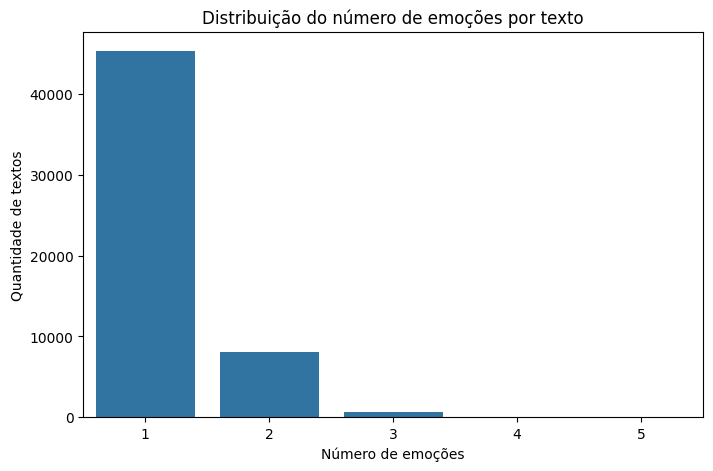

In [6]:
plt.figure(figsize=(8,5))
sns.countplot(x='num_emotions', data=df)
plt.title('Distribuição do número de emoções por texto')
plt.xlabel('Número de emoções')
plt.ylabel('Quantidade de textos')
plt.show()

In [7]:
multi_label_df = df[df['num_emotions'] > 1]

print(f"Total de textos multi-label: {len(multi_label_df)}")
print(f"Percentual: {len(multi_label_df) / len(df):.2%}")

Total de textos multi-label: 8816
Percentual: 16.26%


In [13]:
def get_emotions(row):
    return [emo for emo in emotion_cols if row[emo] == 1]

examples = multi_label_df.sample(5, random_state=42)

for _, row in examples.iterrows():
    print("Texto:")
    print(row['text'])
    print(row['BASE_TEXT_PT'])
    print("Emoções:", get_emotions(row))
    print("-" * 80)

Texto:
I like you, do you like me? Please circle Yes No
gosto voce voce gosta mim por favor circule sim nao
Emoções: ['curiosity', 'love']
--------------------------------------------------------------------------------
Texto:
A cheater is always a cheater in my book.
trapaceiro sempre trapaceiro meu livro
Emoções: ['annoyance', 'neutral']
--------------------------------------------------------------------------------
Texto:
Not much? Oh honey, it's everything! You two are beautiful! Congratulations!
nao muito querida tudo voces duas sao lindas parabens
Emoções: ['admiration', 'gratitude']
--------------------------------------------------------------------------------
Texto:
I did thank you. Can’t wait to get back over for some games.
agradeci mal posso esperar para voltar para alguns jogos
Emoções: ['excitement', 'gratitude']
--------------------------------------------------------------------------------
Texto:
I don’t set an alarm I naturally wake around 4am. Love my mornings.
nao

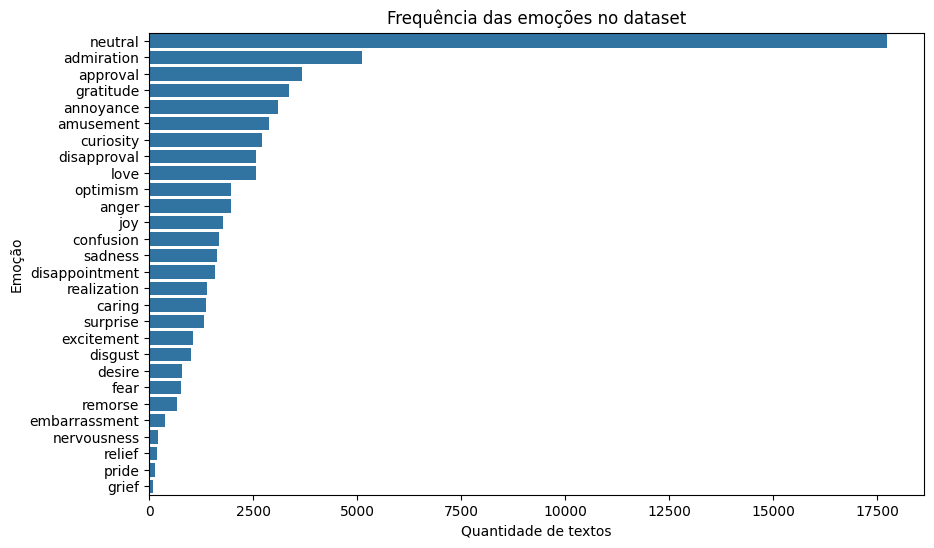

In [14]:
emotion_counts = df[emotion_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=emotion_counts.values, y=emotion_counts.index)
plt.title('Frequência das emoções no dataset')
plt.xlabel('Quantidade de textos')
plt.ylabel('Emoção')
plt.show()

In [15]:
emotion_counts / len(df)

neutral           0.327267
admiration        0.094443
approval          0.067983
gratitude         0.062175
annoyance         0.057031
amusement         0.053343
curiosity         0.050171
disapproval       0.047590
love              0.047498
optimism          0.036435
anger             0.036140
joy               0.032894
confusion         0.030848
sadness           0.029963
disappointment    0.029188
realization       0.025482
caring            0.025353
surprise          0.024505
excitement        0.019379
disgust           0.018678
desire            0.014769
fear              0.014087
remorse           0.012335
embarrassment     0.006914
nervousness       0.003835
relief            0.003356
pride             0.002618
grief             0.001770
dtype: float64

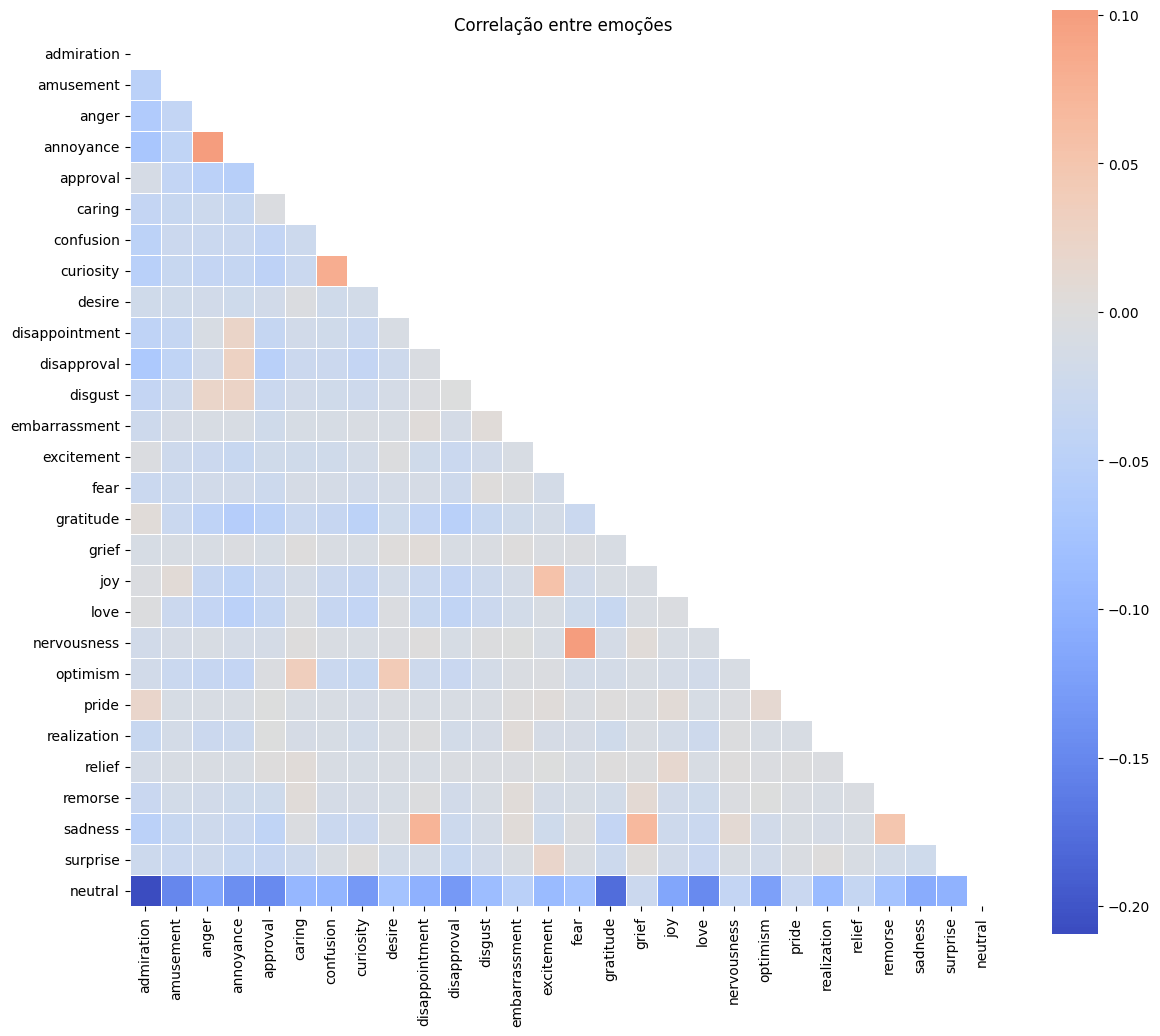

In [18]:
corr = df[emotion_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 12))
sns.heatmap(
    corr,
    mask=mask,
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)
plt.title('Correlação entre emoções')
plt.show()

In [19]:
neutral_with_others = df[
    (df['neutral'] == 1) &
    (df[emotion_cols].sum(axis=1) > 1)
]

print(f"Textos com neutral + outras emoções: {len(neutral_with_others)}")

Textos com neutral + outras emoções: 1750


In [20]:
neutral_cooccurrence = neutral_with_others[emotion_cols].sum().sort_values(ascending=False)

neutral_cooccurrence = neutral_cooccurrence.drop('neutral')
neutral_cooccurrence

approval          258
annoyance         177
curiosity         161
disapproval       134
confusion         119
admiration        117
realization        93
anger              87
disappointment     81
amusement          78
caring             76
sadness            64
optimism           60
joy                53
love               44
surprise           38
excitement         34
disgust            33
desire             29
fear               27
gratitude          17
embarrassment      17
nervousness        11
relief              8
pride               7
remorse             5
grief               3
dtype: int64

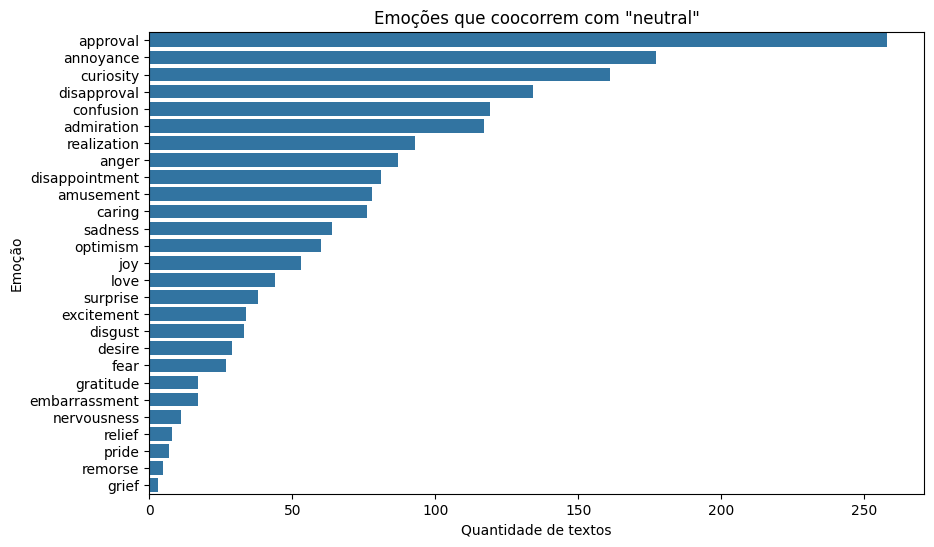

In [21]:
plt.figure(figsize=(10,6))
sns.barplot(
    x=neutral_cooccurrence.values,
    y=neutral_cooccurrence.index
)
plt.title('Emoções que coocorrem com "neutral"')
plt.xlabel('Quantidade de textos')
plt.ylabel('Emoção')
plt.show()

In [24]:
examples_neutral = neutral_with_others.sample(5, random_state=42)

for _, row in examples_neutral.iterrows():
    print("Texto:")
    print(row['text'])
    print(row['BASE_TEXT_PT'])
    print("Emoções:", get_emotions(row))
    print("-" * 80)

Texto:
Well, shrinking of your d could be a motivation to quit porn.
bem diminuir seu pode ser uma motivacao para deixar pornografia
Emoções: ['optimism', 'neutral']
--------------------------------------------------------------------------------
Texto:
Eww that would mean creating a facebook account.
eww isso significaria criar uma conta facebook
Emoções: ['disgust', 'neutral']
--------------------------------------------------------------------------------
Texto:
Mother knows best.
mamae sabe mais
Emoções: ['admiration', 'neutral']
--------------------------------------------------------------------------------
Texto:
>very good teams and perfect situations Situations such as.... [NAME] at the Knicks? Lmao dude, give it up. 
equipes muito boas situacoes perfeitas situacoes como nome nos knicks lmao cara desista
Emoções: ['admiration', 'neutral']
--------------------------------------------------------------------------------
Texto:
Penis who, now?
penis quem agora
Emoções: ['curiosit